# Fault Tolerance via Persistence — LangGraph

A simple workflow to see how **Persistence** (checkpointing) gives
LangGraph **Fault Tolerance** for free.

**Fault Tolerance (recap):**
The ability of a system to keep working correctly, or recover
gracefully, when something goes wrong (a crash, a long delay, a
process getting killed) — instead of losing all progress and
starting over from scratch.

**What it does:**

- A simple 3-node chain: `step_1 → step_2 → step_3 → END`.
- Each node just marks its own state field as `"done"`.
- `step_2` has an artificial DELAY (`time.sleep`) — simulating a
  slow/long-running step where a crash is more likely to happen.
- Because the graph is compiled with a `checkpointer`, LangGraph
  saves a checkpoint after EVERY step. So even if the process were
  killed while `step_2` was sleeping, `step_1`'s result is already
  safely persisted — a resume would not need to redo it.


In [1]:
from typing import TypedDict


class StepState(TypedDict):
    step1: str
    step2: str
    step3: str

In [4]:
import time


def step_1(state: StepState) -> StepState:
    print("Running step_1...")
    return {"step1": "done"}


def step_2(state: StepState) -> StepState:
    print("Running step_2... (sleeping for 10 seconds)")
    time.sleep(30)
    return {"step2": "done"}


def step_3(state: StepState) -> StepState:
    print("Running step_3...")
    return {"step3": "done"}

In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

# define the graph
graph = StateGraph(StepState)

# define nodes
graph.add_node("step_1", step_1)
graph.add_node("step_2", step_2)
graph.add_node("step_3", step_3)

# add edges
graph.add_edge(START, "step_1")
graph.add_edge("step_1", "step_2")
graph.add_edge("step_2", "step_3")
graph.add_edge("step_3", END)

# compile graph — pass the checkpointer here
workflow = graph.compile(checkpointer=checkpointer)

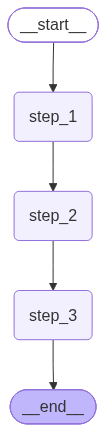

In [6]:
# print/visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [7]:
# execute the graph
config = {"configurable": {"thread_id": "1"}}

initial_state = {"step1": "pending", "step2": "pending", "step3": "pending"}

try:
    final_state = workflow.invoke(initial_state, config=config)
    print(final_state)
except (Exception, KeyboardInterrupt) as e:
    # KeyboardInterrupt fires if you manually interrupt the kernel
    # (e.g. while step_2 is sleeping) — simulating a crash mid-run.
    # Catching it here lets you inspect what already got persisted.
    print(f"Interrupted/failed: {type(e).__name__}: {e}")

Running step_1...
Running step_2... (sleeping for 10 seconds)
Interrupted/failed: KeyboardInterrupt: 


In [8]:
# get_state — see exactly what was persisted, and which node runs "next"
# (if you interrupted during step_2, next will show ('step_2',) or ('step_3',))
print(workflow.get_state(config))

StateSnapshot(values={'step1': 'done', 'step2': 'pending', 'step3': 'pending'}, next=('step_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188e6c-c23e-64fa-8001-9081a6771ca6'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-26T11:40:27.395598+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188e6c-c23c-66e6-8000-80b5493e8713'}}, tasks=(PregelTask(id='15d4f379-b925-90be-f148-ac8bf53450d8', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())


In [9]:
# get_state_history — list of every checkpoint saved for this thread_id
list(workflow.get_state_history(config))


[StateSnapshot(values={'step1': 'done', 'step2': 'pending', 'step3': 'pending'}, next=('step_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188e6c-c23e-64fa-8001-9081a6771ca6'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-26T11:40:27.395598+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188e6c-c23c-66e6-8000-80b5493e8713'}}, tasks=(PregelTask(id='15d4f379-b925-90be-f148-ac8bf53450d8', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'step1': 'pending', 'step2': 'pending', 'step3': 'pending'}, next=('step_1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188e6c-c23c-66e6-8000-80b5493e8713'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-26T11:40:27.394824+00:00', parent_config={'configurable': {'threa